# Évaluation, ajustement et sauvegarde

On reprend exactement la même préparation des données que le Jour 5 (même
filtre, même cible, même split) pour rester comparable. Objectif du jour :
regarder des métriques plus fines que la seule accuracy, comprendre les
limites du modèle du Jour 5, l'ajuster, puis sauvegarder la version finale.

In [9]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

df = pd.read_csv('../data/processed/games_clean.csv', parse_dates=['Release date'])
df['is_indie'] = df['Genres'].fillna('').str.contains('Indie').astype(int)

sub = df[df['total_reviews'] >= 10].copy()
sub['bien_note'] = (sub['positive_ratio'] >= 0.8).astype(int)

top_genres = sub['main_genre'].value_counts().head(10).index
sub['main_genre_group'] = sub['main_genre'].where(sub['main_genre'].isin(top_genres), 'Other')

features_numeriques = [
    'Price', 'Required age', 'DLC count', 'nb_genres',
    'nb_categories', 'nb_tags', 'release_year', 'is_indie'
]
features_categorielles = ['main_genre_group']

X = sub[features_numeriques + features_categorielles]
y = sub['bien_note']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pretraitement = ColumnTransformer([
    ('num', StandardScaler(), features_numeriques),
    ('cat', OneHotEncoder(handle_unknown='ignore'), features_categorielles)
])

## Retour sur le modèle du Jour 5

On ré-entraîne le Random Forest "par défaut" du Jour 5 et on regarde sa
matrice de confusion, sa courbe ROC, et surtout l'écart entre sa performance
sur le train et sur le test.

In [10]:
rf_defaut = Pipeline([
    ('prep', pretraitement),
    ('model', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])
rf_defaut.fit(X_train, y_train)

acc_train = accuracy_score(y_train, rf_defaut.predict(X_train))
acc_test = accuracy_score(y_test, rf_defaut.predict(X_test))
print(f"Accuracy train : {acc_train:.3f}")
print(f"Accuracy test  : {acc_test:.3f}")

Accuracy train : 0.968
Accuracy test  : 0.632


L'écart est énorme : environ 97% sur le train contre 63% sur le test. Le
modèle a quasiment appris le jeu d'entraînement "par cœur" (overfitting),
parce que par défaut les arbres de la forêt n'ont pas de profondeur limite.
C'est exactement le genre de problème qu'on doit corriger avant de garder un
modèle comme version finale.

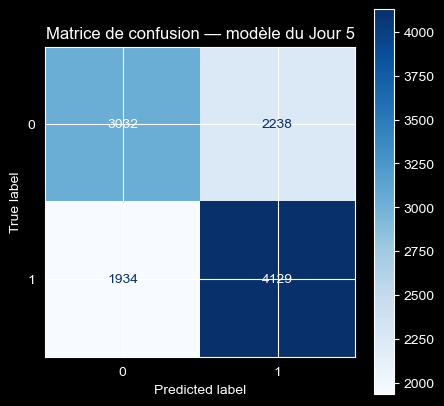

In [11]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_estimator(rf_defaut, X_test, y_test, ax=ax, cmap='Blues')
ax.set_title('Matrice de confusion — modèle du Jour 5')
plt.show()

## Recherche d'hyperparamètres

On cherche des hyperparamètres qui limitent l'overfitting : profondeur
maximale des arbres, nombre minimal d'échantillons par feuille, nombre
d'arbres, et on teste aussi `class_weight='balanced'` au cas où ça aide à
mieux équilibrer les deux classes. On utilise une recherche aléatoire
(`RandomizedSearchCV`) plutôt qu'une grille exhaustive pour rester rapide,
avec une validation croisée à 3 plis et le ROC-AUC comme critère (plus
robuste que l'accuracy quand on compare des modèles).

⚠️ Cette cellule prend environ 2 minutes à s'exécuter.

In [12]:
grille_parametres = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 10, 15, 20, None],
    'model__min_samples_leaf': [1, 2, 5, 10],
    'model__class_weight': [None, 'balanced']
}

recherche = RandomizedSearchCV(
    rf_defaut, grille_parametres, n_iter=12, cv=3,
    scoring='roc_auc', random_state=42, n_jobs=-1
)
recherche.fit(X_train, y_train)

print("Meilleurs paramètres :", recherche.best_params_)
modele_final = recherche.best_estimator_

Meilleurs paramètres : {'model__n_estimators': 300, 'model__min_samples_leaf': 10, 'model__max_depth': 20, 'model__class_weight': 'balanced'}


## Évaluation du modèle ajusté

In [13]:
acc_train_final = accuracy_score(y_train, modele_final.predict(X_train))
acc_test_final = accuracy_score(y_test, modele_final.predict(X_test))

print(f"Accuracy train (ajusté) : {acc_train_final:.3f}")
print(f"Accuracy test (ajusté)  : {acc_test_final:.3f}")
print()
print(classification_report(y_test, modele_final.predict(X_test)))

Accuracy train (ajusté) : 0.711
Accuracy test (ajusté)  : 0.660

              precision    recall  f1-score   support

           0       0.63      0.63      0.63      5270
           1       0.68      0.68      0.68      6063

    accuracy                           0.66     11333
   macro avg       0.66      0.66      0.66     11333
weighted avg       0.66      0.66      0.66     11333



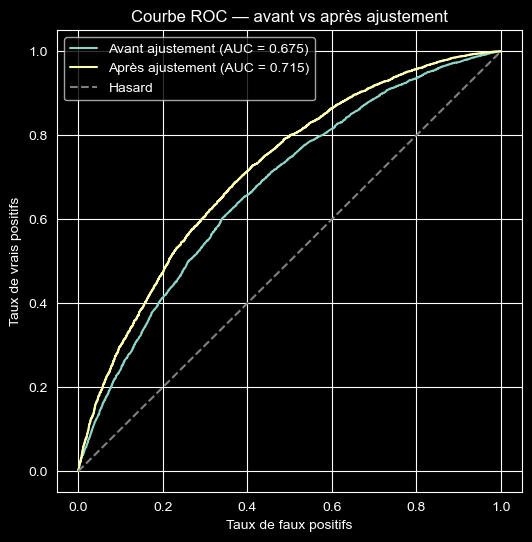

In [14]:
fpr_avant, tpr_avant, _ = roc_curve(y_test, rf_defaut.predict_proba(X_test)[:, 1])
auc_avant = roc_auc_score(y_test, rf_defaut.predict_proba(X_test)[:, 1])

fpr_apres, tpr_apres, _ = roc_curve(y_test, modele_final.predict_proba(X_test)[:, 1])
auc_apres = roc_auc_score(y_test, modele_final.predict_proba(X_test)[:, 1])

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr_avant, tpr_avant, label=f"Avant ajustement (AUC = {auc_avant:.3f})")
ax.plot(fpr_apres, tpr_apres, label=f"Après ajustement (AUC = {auc_apres:.3f})")
ax.plot([0, 1], [0, 1], '--', color='gray', label='Hasard')
ax.set_xlabel('Taux de faux positifs')
ax.set_ylabel('Taux de vrais positifs')
ax.set_title('Courbe ROC — avant vs après ajustement')
ax.legend()
plt.show()

L'ajustement réduit fortement l'écart train/test (le modèle ne mémorise
plus le jeu d'entraînement) et améliore aussi la performance réelle sur le
test : l'accuracy passe d'environ 63% à 66%, et le ROC-AUC d'environ 0,68 à
0,72. Ça reste modeste dans l'absolu (cohérent avec les corrélations
faibles vues au Jour 4), mais c'est une vraie amélioration, et surtout un
modèle plus fiable parce qu'il généralise mieux.

## Quelles variables pèsent le plus ?

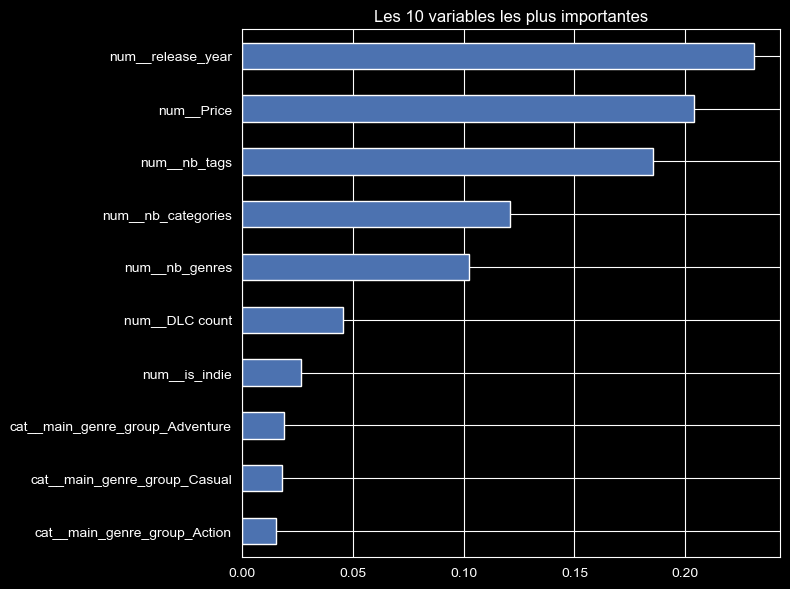

num__release_year                  0.231092
num__Price                         0.203755
num__nb_tags                       0.185373
num__nb_categories                 0.121105
num__nb_genres                     0.102367
num__DLC count                     0.045467
num__is_indie                      0.026585
cat__main_genre_group_Adventure    0.019274
cat__main_genre_group_Casual       0.018129
cat__main_genre_group_Action       0.015331
dtype: float64

In [15]:
noms_features = modele_final.named_steps['prep'].get_feature_names_out()
importances = pd.Series(
    modele_final.named_steps['model'].feature_importances_,
    index=noms_features
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importances.head(10).sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Les 10 variables les plus importantes')
plt.tight_layout()
plt.show()

importances.head(10)

Les variables les plus utiles sont `release_year`, `Price`, `nb_tags` et
`nb_categories` : l'année de sortie et le prix pèsent plus que le genre
pris isolément. Couplé au Jour 4 (où `release_year` et `nb_tags` avaient
les corrélations positives les plus fortes avec `positive_ratio`), ça
confirme que des jeux plus récents et plus richement tagués/catégorisés
(donc probablement mieux décrits et mieux travaillés sur leur page Steam)
ont tendance à être un peu mieux reçus, sans que ce soit un effet décisif.

## Sauvegarde du modèle final

Le pipeline complet (prétraitement + modèle) est sauvegardé en un seul
fichier avec `joblib`, pour pouvoir le recharger directement dans
l'application Streamlit du Jour 7 sans avoir à refaire le split,
l'encodage, etc.

In [16]:
chemin_modele = '../models/modele_bien_note.joblib'
joblib.dump(modele_final, chemin_modele)
print(f"Modèle sauvegardé : {chemin_modele}")

# Vérification rapide : on recharge et on prédit sur quelques lignes du test
modele_recharge = joblib.load(chemin_modele)
print("Prédictions de contrôle :", modele_recharge.predict(X_test.head(5)).tolist())
print("Valeurs réelles        :", y_test.head(5).tolist())

Modèle sauvegardé : ../models/modele_bien_note.joblib
Prédictions de contrôle : [1, 0, 1, 1, 0]
Valeurs réelles        : [1, 0, 1, 0, 0]


## Synthèse

- Le modèle par défaut overfittait fortement (97% train / 63% test)
- Après ajustement des hyperparamètres (profondeur limitée, taille minimale
  des feuilles, pondération des classes), le modèle généralise mieux et
  performe un peu mieux sur le test : ~66% d'accuracy, ROC-AUC ~0,72
- Les variables les plus importantes sont `release_year`, `Price`,
  `nb_tags` et `nb_categories`
- Le pipeline final (prétraitement + modèle) est sauvegardé dans
  `models/modele_bien_note.joblib`